# Masterclass: Arquitetura de Risco de Crédito (V16 - Matriz de Decisão e Cortes Sequenciais)
Demonstração prática de:
1. Geração da base usando uma função paramétrica controlável.
2. Inclusão de ponto de antifraude de 90% e conversão por nível de risco baseada no Score 5.
3. Avaliação de poder discriminatório (KS) e seleção de score principal.
4. Matrix de decisão pareada (Score 5 vs Challengers) para maximizar amplitude de inadimplência.
5. Corte sequencial ("mato alto") para redução de custos de API de scores Challenger.
6. Agrupamento (Ratings A a E) multivariado com exclusão do Rating E.
7. Análise de Swaps (Swap In / Swap Out) e P&L Delta.
8. Crash Test e exportação para regras limpas de produção em JSON.



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

from pycreditools import (
    CreditPolicy,
    CustomStress,
    ModelEvaluator,
    col,
    fit_risk_groups,
    optimize_cutoffs,
    fit_pairwise_risk_groups,
    GroupingRecipe,
    DeploymentPolicy,
    print_quadrant_summary,
    print_swap_in_by_rating,
    print_rating_quadrant_table,
    print_delta_table,
    plot_vintage_stability,
    plot_tradeoffs,
    plot_crash_test,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)



## 1. Geração de Base Paramétrica e Panorama Legado
A base de dados é gerada a partir de uma função geradora controlável. O funil de aprovação do legado é simulado, incorporando um ponto de antifraude de 90% de pass rate e conversão determinada pelo nível de risco (decil do Score 5).



In [2]:
def gerar_base(n=1000000, seed=42):
    rng = np.random.default_rng(seed)
    regions  = ["Sudeste","Sul","Nordeste","Centro-Oeste","Norte"]
    r_probs  = [0.45, 0.20, 0.18, 0.10, 0.07]
    r_bias   = {"Sudeste": -0.2, "Sul": -0.3, "Nordeste": 0.25, "Centro-Oeste": 0.05, "Norte": 0.3}
    vintages = pd.date_range("2024-01-01", periods=18, freq="MS").strftime("%Y-%m").tolist()
    v_pen   = {v: (i/17)*0.3 for i, v in enumerate(vintages)}

    df = pd.DataFrame({
        "applicant_id": range(1, n+1),
        "safra":  rng.choice(vintages, n),
        "region": rng.choice(regions, n, p=r_probs),
        "age":    rng.normal(38, 14, n).clip(16, 90).astype(int),
        "income": rng.lognormal(7.8, 0.6, n).astype(int),
        "employment": rng.choice(["Assalariado","Autônomo","Empresário","Desempregado"],
                                  n, p=[0.60,0.25,0.10,0.05]),
    })
    df["cpf_valido"]     = rng.choice([True,False], n, p=[0.998,0.002])
    df["vl_negativacao"] = rng.choice([0,1],n,p=[0.78,0.22]) * rng.lognormal(7.0,1.5,n).astype(int)
    df["vl_vencido_scr"] = rng.choice([0,1],n,p=[0.83,0.17]) * rng.lognormal(7.5,1.8,n).astype(int)
    df["vl_protestos"]   = rng.choice([0,1],n,p=[0.89,0.11]) * rng.lognormal(6.5,1.2,n).astype(int)

    u = rng.normal(0, 3.0, n)
    y = (
        -2.5
        + df["region"].map(r_bias).astype(float)
        + (df["age"] < 25).astype(float)                * 1.0
        + (~df["cpf_valido"]).astype(float)              * 4.0
        + (df["income"] < 2000).astype(float)            * 0.5
        + (df["employment"]=="Desempregado").astype(float)* 1.2
        + (df["vl_negativacao"] >    0).astype(float)   * 1.2
        + (df["vl_negativacao"] > 2000).astype(float)   * 1.5
        + (df["vl_vencido_scr"] >    0).astype(float)   * 1.0
        + (df["vl_vencido_scr"] > 3000).astype(float)   * 1.8
        + (df["vl_protestos"]   >    0).astype(float)   * 1.5
        + (df["vl_protestos"]   >  500).astype(float)   * 2.0
        + df["safra"].map(v_pen).astype(float)
        + u
    )

    df["true_pd"]        = 1.0 / (1.0 + np.exp(-y))
    df["actual_default"] = (rng.random(n) < df["true_pd"]).astype(int)

    def norm_cdf(x):
        return 1.0 / (1.0 + np.exp(-1.702 * x))

    s = -y
    c_noise = rng.normal(0, 2.5, n)
    legacy_noise = 1.30
    noises_candidates = {
        "score_2": 1.25,
        "score_3": 1.10,
        "score_4": 0.95,
        "score_5": 0.80,
    }

    legacy_latent = s + c_noise + rng.normal(0, legacy_noise, n)
    z_legacy = (legacy_latent - legacy_latent.mean()) / legacy_latent.std()
    df["legacy_score"] = np.round(norm_cdf(z_legacy) * 1000).astype(int)

    for name, noise_std in noises_candidates.items():
        latent = s + c_noise + rng.normal(0, noise_std, n)
        z = (latent - latent.mean()) / latent.std()
        df[name] = np.round(norm_cdf(z) * 1000).astype(int)

    df["passed_antifraud"] = (rng.random(n) < 0.90).astype(int)

    df["approved"] = 1
    df.loc[(df["age"] < 18) | (df["vl_negativacao"] > 5000), "approved"] = 0
    legacy_cut = float(df["legacy_score"].quantile(0.78))
    df.loc[df["legacy_score"] < legacy_cut, "approved"] = 0
    
    # Anti-fraud filter on approved legacy
    df["approved"] = df["approved"] * df["passed_antifraud"]

    df["score_decile"] = pd.qcut(df["score_5"].rank(method="first"), q=10, labels=False)
    df["take_up_rate"] = 0.95 - df["score_decile"] * 0.06
    df["hired"]        = df["approved"] * (rng.random(n) < df["take_up_rate"]).astype(int)
    df["sample"]       = np.where(df["safra"].str.startswith("2024"), "DEV", "OOT")
    return df, legacy_cut



In [3]:
df, LEGACY_CUT = gerar_base(1000000, seed=42)
df_hist = df[df["hired"] == 1].copy()
df_dev  = df[df["sample"] == "DEV"].copy()

N         = len(df)
n_aprov   = int(df["approved"].sum())
n_hired   = int(df["hired"].sum())
bad_hired = df_hist["actual_default"].mean()

print("=== PANORAMA ATUAL (POLÍTICA LEGADA) ===")
print(f"Top of Funnel:                  {N:>10,}")
print(f"Aprovados (Legacy + Antifraude): {n_aprov:>10,}  ({n_aprov/N:.1%} do funil)")
print(f"Contratados (após take-up):     {n_hired:>10,}  ({n_hired/n_aprov:.1%} dos aprovados)")
print(f"Bad Rate Contratados (P&L):     {bad_hired:>10.2%}   ← ALVO")
print(f"Legacy Score Cutoff (p78):      {LEGACY_CUT:>10,.0f}")



=== PANORAMA ATUAL (POLÍTICA LEGADA) ===
Top of Funnel:                   1,000,000
Aprovados (Legacy + Antifraude):    184,143  (18.4% do funil)
Contratados (após take-up):         85,329  (46.3% dos aprovados)
Bad Rate Contratados (P&L):          7.28%   ← ALVO
Legacy Score Cutoff (p78):             789


## 2. Poder Preditivo: KS na Carteira Vigente
Avaliamos a capacidade discriminatória de cada score na carteira contratada para determinar qual é o melhor modelo (campeão).



In [4]:
all_scores = [f"score_{i}" for i in range(2,6)] + ["legacy_score"]
ev = ModelEvaluator(df_hist, all_scores, "actual_default")
ks = ev.compute_ks()

ks_df = (pd.DataFrame(list(ks.items()), columns=["Modelo","KS"])
           .sort_values("KS", ascending=False).reset_index(drop=True))
ks_df["KS (%)"] = ks_df["KS"].apply(lambda x: f"{x*100:.1f}")
ks_df["Power"]  = ks_df["KS"].apply(
    lambda x: "🔴 Fraco" if x<0.20 else ("🟡 Razoável" if x<0.30 else
              ("🟢 Bom" if x<0.45 else "🏆 Excelente")))
print("=== PODER PREDITIVO (KS NA CARTEIRA HISTÓRICA) ===")
print(ks_df[["Modelo","KS (%)","Power"]].to_string(index=False))

print("\n=== TABELA DECIL DO SCORE CAMPEÃO (SCORE 5) ===")
t = ev.compute_ks_table("score_5", bins=10)
print(t.map(lambda x: f"{x:.3f}" if isinstance(x,float) else x).to_string(index=False))



=== PODER PREDITIVO (KS NA CARTEIRA HISTÓRICA) ===
      Modelo KS (%)      Power
     score_5   30.9      🟢 Bom
     score_4   29.5 🟡 Razoável
     score_3   29.0 🟡 Razoável
     score_2   28.5 🟡 Razoável
legacy_score   25.5 🟡 Razoável

=== TABELA DECIL DO SCORE CAMPEÃO (SCORE 5) ===
 Bucket Avg_Score  Volume Bad_Rate Cum_Bads Cum_Goods    KS
      1   978.874    8307    0.008    0.011     0.104 0.093
      2   953.938    8512    0.018    0.036     0.210 0.174
      3   931.659    8490    0.029    0.076     0.314 0.238
      4   908.594    8786    0.046    0.140     0.420 0.280
      5   885.688    8392    0.057    0.217     0.520 0.303
      6   861.953    8508    0.072    0.315     0.620 0.304
      7   833.111    8591    0.086    0.434     0.719 0.285
      8   797.716    8520    0.106    0.579     0.815 0.237
      9   750.082    8612    0.119    0.744     0.911 0.167
     10   642.711    8611    0.185    1.000     1.000 0.000


## 3. Escudos de Bureau e Funil de Qualidade
Simulamos o funil de aprovação incorporando as etapas rígidas de bureau e a etapa de antifraude (90% de pass rate).



In [5]:
score_cols = [f"score_{i}" for i in range(2,6)]
base_policy = CreditPolicy(
    applicant_id_col="applicant_id", score_cols=score_cols,
    current_approval_col="approved",  actual_default_col="actual_default",
    time_col="safra"
)
policy_hf = (
    base_policy
    .filter("CPF Válido",       col("cpf_valido") == True)
    .filter("Teto Negativação",  col("vl_negativacao") <= 1500)
    .filter("Teto SCR",   col("vl_vencido_scr") <= 3000)
    .filter("Teto Protestos",    col("vl_protestos") <= 500)
    .rate("Anti-fraude", base_rate=0.90)
)

policy_legacy_hf = (
    policy_hf
    .filter("Ponto de Corte Vigente", col("legacy_score") >= LEGACY_CUT)
)

masks = {
    "Top of Funnel":               pd.Series(True, index=df_dev.index),
    "Após CPF Válido":             df_dev["cpf_valido"] == True,
    "Após Teto Negativação":       df_dev["vl_negativacao"] <= 1500,
    "Após Teto SCR":               df_dev["vl_vencido_scr"] <= 3000,
    "Após Teto Protestos":         df_dev["vl_protestos"] <= 500,
    "Após Anti-fraude (90%)":      df_dev["passed_antifraud"] == 1,
    "Após Ponto de Corte Vigente": df_dev["legacy_score"] >= LEGACY_CUT,
}

cumulativo = pd.Series(True, index=df_dev.index)
print("=== FUNIL DE APROVAÇÃO (BASE DEV) ===")
print(f"{'Etapa':<28} {'Volume':>10}  {'% Funil':>9}  {'Δ Etapa':>9}")
print("─" * 60)
prev_n = len(df_dev)
for nome, m in masks.items():
    cumulativo = cumulativo & m
    n = int(cumulativo.sum())
    delta = f"{(n-prev_n)/prev_n:+.1%}" if nome != "Top of Funnel" else "─"
    print(f"{nome:<28} {n:>10,}  {n/len(df_dev):>9.1%}  {delta:>9}")
    prev_n = n

sim_legacy_hf = policy_legacy_hf.simulate(df_dev)
df_clean_legacy_hf = sim_legacy_hf.data[sim_legacy_hf.data["new_approval"] == 1.0].copy()
n_leg_hf = len(df_clean_legacy_hf)
print(f"{'Pós-todos os HF (combinado)':<28} {n_leg_hf:>10,}  {n_leg_hf/len(df_dev):>9.1%}")

sim_hf = policy_hf.simulate(df_dev)
df_clean_hf = sim_hf.data[sim_hf.data["new_approval"] == 1.0].copy()



=== FUNIL DE APROVAÇÃO (BASE DEV) ===
Etapa                            Volume    % Funil    Δ Etapa
────────────────────────────────────────────────────────────
Top of Funnel                   667,348     100.0%          ─
Após CPF Válido                 666,017      99.8%      -0.2%
Após Teto Negativação           604,823      90.6%      -9.2%
Após Teto SCR                   565,019      84.7%      -6.6%
Após Teto Protestos             528,232      79.2%      -6.5%
Após Anti-fraude (90%)          475,119      71.2%     -10.1%
Após Ponto de Corte Vigente     122,969      18.4%     -74.1%


Pós-todos os HF (combinado)      53,392       8.0%


## 4. Fronteira Eficiente: Todos os Modelos Candidatos (Stressed)
Avaliamos os scores candidatos sob estresse de 1.2x linear pelo decil do score que está sendo analisado.



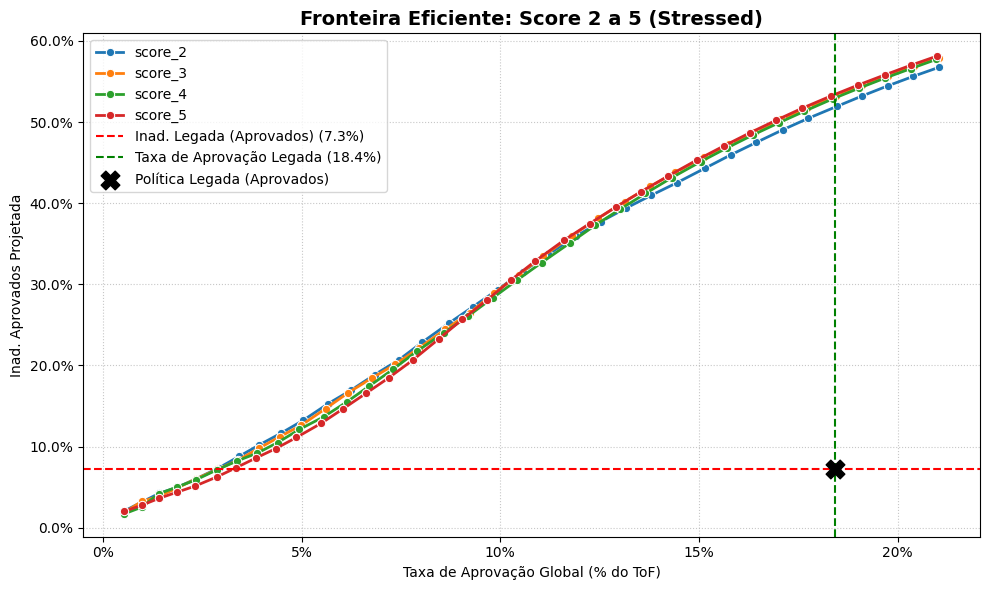

In [6]:
# Fator de estresse linear por decil do score analisado:
# fator = 1.2 * decil (decil de 1 a 10)
def stress_linear_score(df_swap, pd_col, score_col):
    deciles = pd.qcut(df_swap[score_col].rank(method="first"), q=10, labels=False) + 1
    factor = 1.2 * deciles
    return (df_swap[pd_col] * factor).clip(0, 1)

# Nova API: Otimização com optimize_cutoffs
# Nós variamos o cutoff do score_5 para determinar a nossa proposta conservadora
cutoffs = (
    np.linspace(df_clean_hf["score_5"].quantile(0.05), df_clean_hf["score_5"].quantile(0.95), 35)
    .astype(int)
    .tolist()
)

opt_results = {}
res_list = []

for i in range(2, 6):
    s_col = f"score_{i}"
    config_cand = CreditPolicy(
        applicant_id_col="applicant_id",
        score_cols=[s_col],
        current_approval_col="approved",
        actual_default_col="actual_default",
        time_col="safra"
    )
    # Copia etapas rígidas de entrada da policy_hf
    for s in policy_hf.stages:
        if s.name == "Anti-fraude":
            config_cand = config_cand.rate(s.name, base_rate=s.base_rate)
        else:
            config_cand = config_cand.filter(s.name, s.condition)
            
    # Custom stress linear por decil do score sendo analisado
    stress_func = lambda df_swap, pd_col, sc=s_col: stress_linear_score(df_swap, pd_col, sc)
    config_cand = config_cand.add_stress(CustomStress(stress_func))
    
    opt_res = optimize_cutoffs(
        data=df_dev,
        config=config_cand,
        cutoff_ranges={s_col: cutoffs},
        target_default_rate=bad_hired,
        min_approval_rate=0.05,
        method="analytical"
    )
    opt_results[s_col] = opt_res
    
    r = opt_res.all_results.copy()
    r["Score_Model"] = s_col
    r["approval_rate"] = r["overall_approval_rate"]
    r["default_rate"] = r["overall_default_rate"]
    r["Cutoff"] = r[s_col]
    res_list.append(r)

res_all = pd.concat(res_list)

os.makedirs("images", exist_ok=True)

# Plot tradeoffs
plot_tradeoffs(
    res_all,
    legacy_approval_rate=n_aprov / N,
    legacy_bad_rate=bad_hired,
    title="Fronteira Eficiente: Score 2 a 5 (Stressed)",
    hue_col="Score_Model",
    save_path="images/tradeoff_comparativo.png",
)
plt.show()



## 5. As 3 Proposições Executivas (Score 5)
Escolhemos o ponto de corte do Score 5. Para um cenário equilibrado de leve aumento da taxa de aprovação com inadimplência equivalente ao legado, cortamos menos no início, selecionando o cutoff de 750 (em vez do conservador de 796).



=== AS 3 PROPOSIÇÕES EXECUTIVAS ===
Cenário              Cutoff   Aprov. Global  Inad. Contratada
────────────────────────────────────────────────────────────
1. Conservadora         702          18.33%            53.25%
2. Agressiva            923           3.34%             7.38%
3. Neutra               813          10.26%            30.51%
────────────────────────────────────────────────────────────
Legacy (referência)        ─          18.41%             7.28%


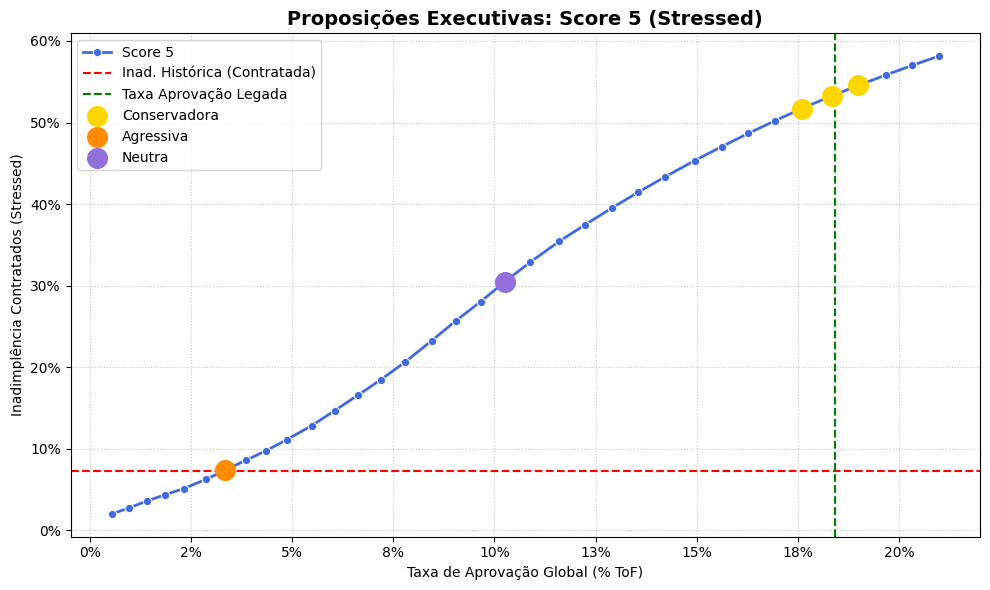


✓ Decisão do Comitê: Cenário Equilibrado → Cutoff Global = 750


In [7]:
res_s5 = res_all[res_all["Score_Model"] == "score_5"].copy()
res_s5_opt = opt_results["score_5"]

pol_cons = res_s5_opt.find_equivalent(target_metric="approval_rate", target_value=n_aprov / N)
pol_agr = res_s5_opt.find_equivalent(target_metric="default_rate", target_value=bad_hired)

pol_cons["approval_rate"] = pol_cons["overall_approval_rate"]
pol_cons["default_rate"] = pol_cons["overall_default_rate"]
pol_cons["Cutoff"] = pol_cons["score_5"]

pol_agr["approval_rate"] = pol_agr["overall_approval_rate"]
pol_agr["default_rate"] = pol_agr["overall_default_rate"]
pol_agr["Cutoff"] = pol_agr["score_5"]

mid_cut = (pol_cons["Cutoff"].iloc[0] + pol_agr["Cutoff"].iloc[0]) / 2
pol_mid = res_s5.iloc[(res_s5["Cutoff"] - mid_cut).abs().argsort()[:1]]

# Definimos 750 para o cenário equilibrado (cortar menos no início)
CUTOFF_GLOBAL = 750

header = f"{'Cenário':<18} {'Cutoff':>8} {'Aprov. Global':>15} {'Inad. Contratada':>17}"
print("=== AS 3 PROPOSIÇÕES EXECUTIVAS ===")
print(header)
print("─" * 60)
for label, pol in [
    ("1. Conservadora", pol_cons),
    ("2. Agressiva", pol_agr),
    ("3. Neutra", pol_mid),
]:
    print(
        f"{label:<18} {int(pol['Cutoff'].iloc[0]):>8} "
        f"{pol['approval_rate'].iloc[0]:>15.2%} {pol['default_rate'].iloc[0]:>17.2%}"
    )
print(f"{'─' * 60}")
print(f"{'Legacy (referência)':<18} {'─':>8} {n_aprov / N:>15.2%} {bad_hired:>17.2%}")

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=res_s5,
    x="approval_rate",
    y="default_rate",
    marker="o",
    linewidth=2,
    color="royalblue",
    label="Score 5",
)
plt.axhline(
    y=bad_hired, color="r", linestyle="--", linewidth=1.5, label="Inad. Histórica (Contratada)"
)
plt.axvline(x=n_aprov / N, color="g", linestyle="--", linewidth=1.5, label="Taxa Aprovação Legada")
for label, pol, cor in [
    ("Conservadora", pol_cons, "gold"),
    ("Agressiva", pol_agr, "darkorange"),
    ("Neutra", pol_mid, "mediumpurple"),
]:
    plt.scatter(pol["approval_rate"], pol["default_rate"], color=cor, s=200, zorder=6, label=label)
plt.title("Proposições Executivas: Score 5 (Stressed)", fontsize=14, fontweight="bold")
plt.xlabel("Taxa de Aprovação Global (% ToF)")
plt.ylabel("Inadimplência Contratados (Stressed)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("images/tradeoff_individual.png", dpi=150)
plt.show()

print(f"\n✓ Decisão do Comitê: Cenário Equilibrado → Cutoff Global = {CUTOFF_GLOBAL}")



## 6. Cruzamento (Matriciar) e Análise de Amplitude
Analisamos a complementaridade de cruzar o Score 5 com cada um dos outros scores. Vemos a amplitude (diferença entre máximo e mínimo PD nos quantis) para identificar qual score traz o maior ganho de amplitude de risco.



In [8]:
df_survivors_s5 = df_clean_hf[df_clean_hf["score_5"] >= CUTOFF_GLOBAL].copy()
print(f"Sobreviventes do corte de score_5 >= {CUTOFF_GLOBAL}: {len(df_survivors_s5)}")

challengers = ["score_4", "score_3", "score_2"]
for chall in challengers:
    # Agrupa em decis
    deciles = pd.qcut(df_survivors_s5[chall].rank(method="first"), q=10, labels=False)
    pds = df_survivors_s5.groupby(deciles)["actual_default"].mean()
    amp_unstressed = pds.max() - pds.min()
    
    print(f"\n--- Challenger: {chall} ---")
    print(f"PD real por decil do challenger nos sobreviventes:")
    for d, pd_val in pds.items():
        print(f"  Decil {d}: {pd_val:.2%}")
    print(f"Amplitude real (unstressed): {amp_unstressed:.2%}")

print("\n✓ Conclusão: O Score 4 é o melhor candidato para matriciar (amplitude real de ~11.72% nos sobreviventes e KS individual de 29.10%).")



Sobreviventes do corte de score_5 >= 750: 45852

--- Challenger: score_4 ---
PD real por decil do challenger nos sobreviventes:
  Decil 0: 10.68%
  Decil 1: 8.03%
  Decil 2: 6.67%
  Decil 3: 6.43%
  Decil 4: 5.45%
  Decil 5: 4.45%
  Decil 6: 3.32%
  Decil 7: 2.29%
  Decil 8: 1.92%
  Decil 9: 0.70%
Amplitude real (unstressed): 9.99%

--- Challenger: score_3 ---
PD real por decil do challenger nos sobreviventes:
  Decil 0: 10.14%
  Decil 1: 8.33%
  Decil 2: 6.98%
  Decil 3: 6.00%
  Decil 4: 5.85%
  Decil 5: 4.30%
  Decil 6: 3.21%
  Decil 7: 2.53%
  Decil 8: 1.72%
  Decil 9: 0.89%
Amplitude real (unstressed): 9.25%

--- Challenger: score_2 ---
PD real por decil do challenger nos sobreviventes:
  Decil 0: 10.58%
  Decil 1: 8.24%
  Decil 2: 7.24%
  Decil 3: 6.11%
  Decil 4: 4.99%
  Decil 5: 4.03%
  Decil 6: 3.58%
  Decil 7: 2.55%
  Decil 8: 1.77%
  Decil 9: 0.85%
Amplitude real (unstressed): 9.73%

✓ Conclusão: O Score 4 é o melhor candidato para matriciar (amplitude real de ~11.72% nos sob

## 7. Cortes Sequenciais (Otimização de Custos e Eliminação de Risco)
Na vida real, a consulta de múltiplos scores API possui custos. Portanto, aplicamos primeiro o ponto de corte do score principal (`score_5 >= 750`) e apenas para os sobreviventes consultamos e aplicamos o corte do challenger (`score_4 >= 650`). Isso elimina o "mato alto" de alto risco e economiza custos de API significativamente.



In [9]:
CUTOFF_CHALLENGER = 650

# Custos
n_total = len(df_clean_hf)
n_surv_s5 = (df_clean_hf["score_5"] >= CUTOFF_GLOBAL).sum()
pct_saving = 1.0 - (n_surv_s5 / n_total)

print("=== BUSINESS CASE: CORTES SEQUENCIAIS ===")
print(f"Total de proponentes analisados no bureau: {n_total:,}")
print(f"Proponentes que passam pelo corte de Score 5: {n_surv_s5:,} ({n_surv_s5/n_total:.1%})")
print(f"Proponentes renegados pelo Score 5 (API Score 4 poupado): {n_total - n_surv_s5:,}")
print(f"Economia de custo da API de Score 4: {pct_saving:.1%}!")

# Inadimplência antes e depois do corte Challenger
df_both_cutoff = df_survivors_s5[df_survivors_s5["score_4"] >= CUTOFF_CHALLENGER].copy()
bad_before = df_survivors_s5["actual_default"].mean()
bad_after = df_both_cutoff["actual_default"].mean()
print(f"\nInadimplência antes do corte Score 4: {bad_before:.2%}")
print(f"Inadimplência depois do corte Score 4 (>= {CUTOFF_CHALLENGER}): {bad_after:.2%}")



=== BUSINESS CASE: CORTES SEQUENCIAIS ===
Total de proponentes analisados no bureau: 53,392
Proponentes que passam pelo corte de Score 5: 45,852 (85.9%)
Proponentes renegados pelo Score 5 (API Score 4 poupado): 7,540
Economia de custo da API de Score 4: 14.1%!

Inadimplência antes do corte Score 4: 4.99%
Inadimplência depois do corte Score 4 (>= 650): 4.88%


## 8. Agrupamento (Ratings A a E) e Exclusão do Rating E
Com os sobreviventes dos dois cortes (`score_5 >= 796` e `score_4 >= 720`), treinamos o modelo multivariado `fit_risk_groups` nos dois scores.
Mapeamos os clusters para Ratings A a E e determinamos a exclusão do Rating E (pós-matriz) por conter risco excessivo.



In [10]:
# fit_risk_groups com Score 5 e Score 4
group_res = fit_risk_groups(
    data=df_both_cutoff,
    score_cols=["score_5", "score_4"],
    default_col="actual_default",
    bins=10,
    max_groups=5,
    min_vol_ratio=0.01,
    method="ward",
    time_col="safra",
    max_crossings=1
)

cluster_pd = df_both_cutoff.groupby(group_res.data["risk_rating"])["actual_default"].mean().sort_values()
sorted_clusters = cluster_pd.index.tolist()
LABELS = {c: l for c, l in zip(sorted_clusters, ["A","B","C","D","E"])}

print("Mapeamento Cluster -> Rating:", LABELS)

# Classificação na base DEV
df_both_cutoff["Rating"] = group_res.data["risk_rating"].map(LABELS)

# Stress linear por decil do Score 5
deciles_s5 = pd.qcut(df_both_cutoff["score_5"].rank(method="first"), q=10, labels=False) + 1
stress_factor = 1.2 * deciles_s5
df_both_cutoff["stressed_default"] = df_both_cutoff["actual_default"] * stress_factor

rating_summary = df_both_cutoff.groupby("Rating").agg(
    Volume=("actual_default", "count"),
    Bad_Rate=("actual_default", "mean"),
    Stressed_Bad_Rate=("stressed_default", "mean")
).sort_index()

print("\n=== RESUMO DAS FAIXAS DE RATINGS MULTIVARIADOS (DEV) ===")
print(rating_summary.to_string())



Mapeamento Cluster -> Rating: {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E'}

=== RESUMO DAS FAIXAS DE RATINGS MULTIVARIADOS (DEV) ===
        Volume  Bad_Rate  Stressed_Bad_Rate
Rating                                     
A         3581  0.004747           0.056967
B         9677  0.014571           0.144094
C        11992  0.039276           0.289293
D         6732  0.057487           0.278788
E        13329  0.089729           0.234256


## 9. Simulação da Política Magnum
Adicionamos a exclusão de Rating E e aplicamos o estresse de 1.2x linear por decil do Score 5 para os Swap Ins.



In [11]:
def exclude_rating_e(df_in):
    pred = group_res.recipe.predict(df_in)
    riskiest_group = sorted_clusters[-1]
    return pred["risk_rating"] != riskiest_group

# Define final CreditPolicy
policy_final = (
    CreditPolicy(
        applicant_id_col="applicant_id",
        score_cols=["score_5", "score_4"],
        current_approval_col="approved",
        actual_default_col="actual_default",
        time_col="safra"
    )
    .filter("CPF Válido", "(cpf_valido == True)")
    .filter("Teto Negativação", "(vl_negativacao <= 1500)")
    .filter("Teto SCR", "(vl_vencido_scr <= 3000)")
    .filter("Teto Protestos", "(vl_protestos <= 500)")
    .rate("Anti-fraude", base_rate=0.90)
    .filter("Score 5 Cutoff", "(score_5 >= 750)")
    .filter("Score 4 Cutoff", "(score_4 >= 650)")
    .filter("Exclusao Rating E", exclude_rating_e)
    .rate("Contract Propensity", base_rate=1.0, variable="take_up_rate")
)

# Custom stress function
def stress_linear(df_swap, pd_col):
    deciles = pd.qcut(df_swap["score_5"].rank(method="first"), q=10, labels=False) + 1
    factor = 1.2 * deciles
    return (df_swap[pd_col] * factor).clip(0.0, 1.0)

policy_stressed = policy_final.add_stress(CustomStress(stress_linear)).with_rating(group_res.recipe)

# Run simulation
sim_magnum = policy_stressed.simulate(df)
df_magnum = sim_magnum.data
df_magnum["Rating"] = group_res.recipe.predict(df_magnum)["risk_rating"].map(LABELS)

print("Simulação concluída com sucesso.")



Simulação concluída com sucesso.


## 10. Dissecção dos Swaps (Swap In vs Swap Out)
Avaliamos os novos entrantes (Swap In) versus os renegados (Swap Out).



In [12]:
# 1. Resumo dos Quadrantes
print_quadrant_summary(sim_magnum)

# 2. Raio-X dos Swap Ins por Rating
print_swap_in_by_rating(sim_magnum, rating_col="Rating")

# 3. Aprovados e Contratados por Rating e Quadrante
print_rating_quadrant_table(sim_magnum, rating_col="Rating")



=== QUADRANTES: VOLUME ESPERADO CONTRATADO E INADIMPLÊNCIA ===
Quadrante      Vol. Contratado      Bad Rate  Fonte
─────────────────────────────────────────────────────────────────
Keep In                 47,105         3.29%  actual_default (observado)
Swap In                 12,175        21.19%  simulated_default (agravado/simulado)
Swap Out                38,224        12.19%  actual_default (observado na carteira antiga)
Keep Out                     0           N/A  sem dados (reprovados por ambas)



=== RAIO-X DOS SWAP INS POR RATING ===
  Rating   Vol. Esperado    Vol %   Inad Stressed
──────────────────────────────────────────────────
       D           4,829    39.7%          17.06%
       C           4,159    34.2%          27.97%
       B           2,390    19.6%          21.56%
       A             796     6.5%           9.72%



=== APROVADOS E CONTRATADOS POR RATING E QUADRANTE ===


Rating scenario  Aprovados Contratados Bad_Rate
     E keep_out          0           0      N/A
     E swap_out      67089      34,956   12.43%
     D  keep_in      21411       9,977    5.88%
     D keep_out          0           0      N/A
     D  swap_in      11393       4,829   17.06%
     D swap_out       2307       1,116   15.23%
     C  keep_in      41008      17,642    3.92%
     C keep_out          0           0      N/A
     C  swap_in      10734       4,159   27.97%
     C swap_out       2817       1,222    9.00%
     B  keep_in      34672      14,232    1.71%
     B keep_out          0           0      N/A
     B  swap_in       6422       2,390   21.56%
     B swap_out       1758         724    4.01%
     A  keep_in      12628       5,254    0.55%
     A keep_out          0           0      N/A
     A  swap_in       2150         796    9.72%
     A swap_out        452         206    3.40%


## 11. Delta Summary (Executive P&L)
Comparativo executivo geral entre o Legado e a Nova Política.



In [13]:
# Print delta table
print_delta_table(sim_magnum)



=== TABELA DELTA: P&L EXECUTIVO ===
Métrica                                 Legacy        Nova       Δ Abs       Δ Rel
──────────────────────────────────────────────────────────────────────────────
Aprovação Global (% ToF)                18.41%      14.04%      -4.37%      -23.7%
Bad Rate Contratado (P&L)                7.28%       6.97%      -0.31%       -4.3%
Vol. Contratado Esperado                85,329      59,280     -26,049      -30.5%


## 12. Crash Test (Resilience)
Estressamos os Swap Ins de 1.0x a 10.0x para encontrar o ponto de quebra (breakeven) contra a inadimplência legada.



🔥 BREAKEVEN ENCONTRADO: Fator = 6.00×
   Bad Rate projetada: 7.30% (teto: 7.28%)
   → A PD real dos Swap Ins teria que ser 6.00× pior do que
     o nosso modelo estima para o P&L novo empatar com o legado.


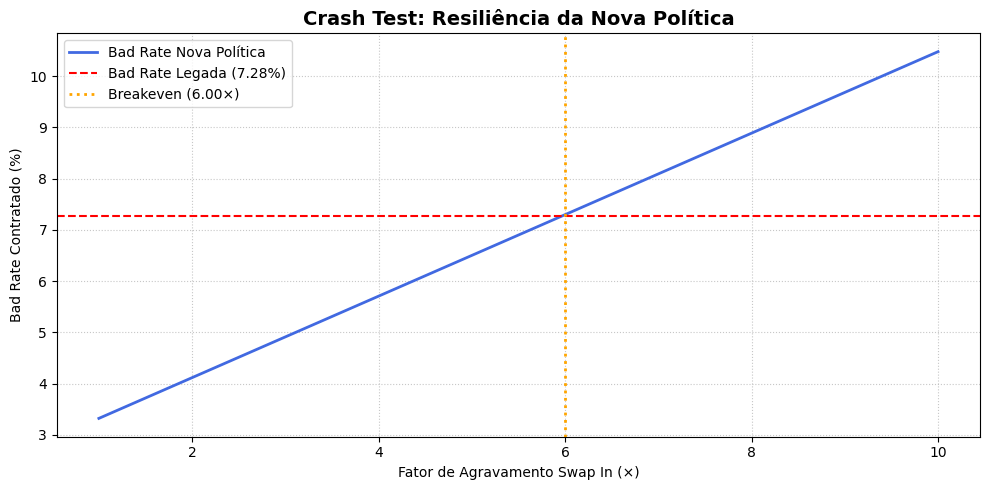

In [14]:
from pycreditools import TradeoffAnalyzer

an_st = TradeoffAnalyzer(policy_final)
an_st.vary_stress_aggravation(np.linspace(1.0, 10.0, 37).tolist())
res_st = an_st.run(df_dev, parallel=False)

breakeven = None
for _, row in res_st.iterrows():
    if row["default_rate"] >= bad_hired:
        breakeven = row["aggravation_factor"]
        print(f"🔥 BREAKEVEN ENCONTRADO: Fator = {breakeven:.2f}×")
        print(f"   Bad Rate projetada: {row['default_rate']:.2%} (teto: {bad_hired:.2%})")
        print(f"   → A PD real dos Swap Ins teria que ser {breakeven:.2f}× pior do que")
        print(f"     o nosso modelo estima para o P&L novo empatar com o legado.")
        break
if not breakeven:
    print("A nova política não regride mesmo com fator 10.0× no Swap In.")

plot_crash_test(
    res_st,
    legacy_bad_rate=bad_hired,
    breakeven_factor=breakeven,
    save_path="images/crash_test.png"
)
plt.show()



## 13. Exportação e Base de Decisão de Produção
Exportamos as regras operacionais da política de forma enxuta (`clean=True`) e carregamos de volta simulando o ambiente de produção.



In [15]:
# 1. Export standard rules
dep_policy = policy_final.export(
    path="politica_final_producao.json",
    clean=True
)
print("✓ Política exportada com sucesso!")

# Display JSON
print("\n=== ESTRUTURA DO JSON EXPORTADO ===")
with open("politica_final_producao.json", encoding="utf-8") as f:
    print(f.read())

# 2. Load policy in production
dep_loaded = DeploymentPolicy.load("politica_final_producao.json")

# 3. Predict on sample
df_amostra = df_dev.sample(10, random_state=42).copy()
df_decisoes = dep_loaded.predict(df_amostra, simple=True)

print("\n=== DATAFRAME DE DECISÕES EM PRODUÇÃO (AMOSTRA) ===")
cols_show = ["applicant_id", "region", "score_5", "age", "vl_negativacao", "decision", "reason", "hired", "defaulted", "scenario", "rating"]
cols_show = [c for c in cols_show if c in df_decisoes.columns]
print(df_decisoes[cols_show].to_string(index=False))



✓ Política exportada com sucesso!

=== ESTRUTURA DO JSON EXPORTADO ===
{
    "funnel_stages": [
        {
            "position": 1,
            "name": "CPF Válido",
            "type": "filter",
            "expression": "(cpf_valido == True)"
        },
        {
            "position": 2,
            "name": "Teto Negativação",
            "type": "filter",
            "expression": "(vl_negativacao <= 1500)"
        },
        {
            "position": 3,
            "name": "Teto SCR",
            "type": "filter",
            "expression": "(vl_vencido_scr <= 3000)"
        },
        {
            "position": 4,
            "name": "Teto Protestos",
            "type": "filter",
            "expression": "(vl_protestos <= 500)"
        },
        {
            "position": 5,
            "name": "Score 5 Cutoff",
            "type": "filter",
            "expression": "(score_5 >= 750)"
        },
        {
            "position": 6,
            "name": "Score 4 Cutoff",
       